# Q-factorisation on Gridworld Maze using Successor Measure.

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from copy import deepcopy

import copy
from typing import Callable, Optional




# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.maze_discrete import MazeGridWorld, MazeGoalWrapper
from utils import (TrajectoryReplayBufferDiscrete, evaluate_policy, set_seed, build_goal_batch, get_base_env, collect_valid_states_fourrooms,
                   estimate_fisher_diag, extract_fixed_probe_sa_embedding, extract_mean_sa_embedding, extract_sa_batch_for_isotropy,
                   compute_embedding_drift, collect_weight_snapshot, get_free_cells, sample_goals, plot_sa_encoder_changes_across_tasks, compute_weight_change_from_snapshots)
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_html, plot_min_steps_and_min_time
from loss_functions import repulsion_loss_to_memory, sigreg_loss, orthogonal_loss, ewc_regulariser_loss, weight_regulariser_loss
from networks import snapshot_named_parameters, FactorisedSuccessorDQN
from trainer import dqn_train_new


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


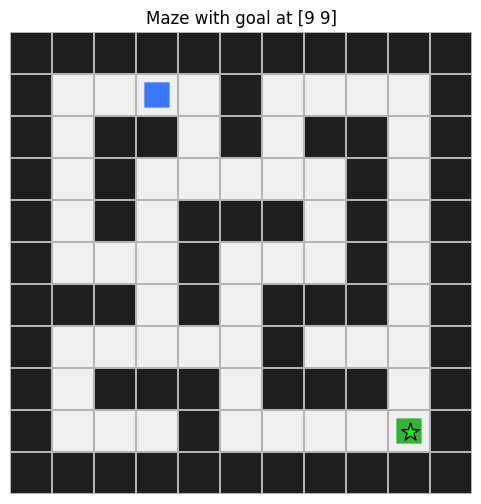

In [2]:
MAZE_LAYOUT = [
    [1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1],
]

def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=100):
    base = MazeGridWorld(
        maze=MAZE_LAYOUT,
        max_episode_steps=max_horizon,
    )
    env = MazeGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
        reward_mode="simple",
    )
    return env

env = make_env(goal=(9, 9))
obs, info = env.reset()

img = env.unwrapped.render()
goal = env.goal_position

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.scatter(
    goal[0] * 40 + 20,
    goal[1] * 40 + 20,
    c="lime",
    s=180,
    marker="*",
    edgecolors="black",
)
plt.title(f"Maze with goal at {goal}")
plt.axis("off")
plt.show()

In [3]:
def make_state_to_index_fn(
    min_x: int,
    min_y: int,
    width: int,
):
    def state_to_index(obs: torch.Tensor) -> torch.Tensor:
        x = obs[:, 0].long()
        y = obs[:, 1].long()

        return (y - min_y) * width + (x - min_x)

    return state_to_index

def make_one_hot_maze_feature_fn(
    state_to_index,
    num_states: int,
    wall_feature_index: int | None = None,
):
    """
    Returns a function:

        immediate_feature_fn(
            next_obs,
            goal,
            collision,
        ) -> [B, num_states + 1]

    The goal argument is accepted for API compatibility,
    but the immediate state feature itself is task-independent.
    """

    if wall_feature_index is None:
        wall_feature_index = num_states

    rep_dim = num_states + 1

    def immediate_feature_fn(
        next_obs: torch.Tensor,
        goal: torch.Tensor,
        collision: torch.Tensor,
    ) -> torch.Tensor:
        del goal

        batch_size = next_obs.shape[0]

        state_ids = state_to_index(next_obs)
        state_ids = state_ids.clamp(
            min=0,
            max=num_states - 1,
        )

        features = torch.zeros(
            batch_size,
            rep_dim,
            device=next_obs.device,
            dtype=next_obs.dtype,
        )

        batch_indices = torch.arange(
            batch_size,
            device=next_obs.device,
        )

        features[
            batch_indices,
            state_ids,
        ] = 1.0

        collision = collision.reshape(-1).to(
            dtype=features.dtype,
            device=features.device,
        )

        features[:, wall_feature_index] = collision

        return features

    return immediate_feature_fn

def _to_float_tensor(
    value,
    device,
    dtype=torch.float32,
):
    return torch.as_tensor(
        value,
        device=device,
        dtype=dtype,
    )


def _ensure_column(
    value: torch.Tensor,
) -> torch.Tensor:
    if value.ndim == 0:
        return value.reshape(1, 1)

    if value.ndim == 1:
        return value.unsqueeze(-1)

    return value


def _ensure_done_column(
    value: torch.Tensor,
    device,
) -> torch.Tensor:
    value = torch.as_tensor(
        value,
        device=device,
    )

    if value.ndim == 0:
        value = value.reshape(1, 1)
    elif value.ndim == 1:
        value = value.unsqueeze(-1)

    return value.float()


def _action_onehot(
    actions: torch.Tensor,
    num_actions: int,
) -> torch.Tensor:
    if actions.ndim > 1:
        actions = actions.squeeze(-1)

    return F.one_hot(
        actions.long(),
        num_classes=num_actions,
    ).float()


def _expand_goal(
    goal_tensor: torch.Tensor,
    batch_size: int,
) -> torch.Tensor:
    if goal_tensor.shape[0] == 1:
        return goal_tensor.expand(
            batch_size,
            -1,
        )

    if goal_tensor.shape[0] != batch_size:
        raise ValueError(
            "Goal batch has an incompatible batch dimension: "
            f"{goal_tensor.shape[0]} versus {batch_size}."
        )

    return goal_tensor


def _soft_update(
    online_network: nn.Module,
    target_network: nn.Module,
    tau: float,
) -> None:
    with torch.no_grad():
        for online_parameter, target_parameter in zip(
            online_network.parameters(),
            target_network.parameters(),
        ):
            target_parameter.mul_(1.0 - tau)
            target_parameter.add_(
                tau * online_parameter
            )


def _freeze_target_network(
    network: nn.Module,
) -> None:
    network.eval()

    for parameter in network.parameters():
        parameter.requires_grad_(False)


def _flatten_gradients(
    loss: torch.Tensor,
    parameters,
) -> torch.Tensor:
    parameters = list(parameters)

    gradients = torch.autograd.grad(
        loss,
        parameters,
        retain_graph=True,
        allow_unused=True,
    )

    flat_gradients = []

    for parameter, gradient in zip(
        parameters,
        gradients,
    ):
        if gradient is None:
            flat_gradients.append(
                torch.zeros_like(
                    parameter
                ).reshape(-1)
            )
        else:
            flat_gradients.append(
                gradient.detach().reshape(-1)
            )

    if len(flat_gradients) == 0:
        return torch.empty(
            0,
            device=loss.device,
        )

    return torch.cat(flat_gradients)


def _cosine_similarity_or_zero(
    first: torch.Tensor,
    second: torch.Tensor,
) -> float:
    if first.numel() == 0:
        return 0.0

    if second.numel() == 0:
        return 0.0

    if first.norm().item() == 0.0:
        return 0.0

    if second.norm().item() == 0.0:
        return 0.0

    return F.cosine_similarity(
        first.unsqueeze(0),
        second.unsqueeze(0),
        dim=-1,
    ).item()


def dqn_train_successor_features(
    seed: int = 42,
    q_network: Optional[nn.Module] = None,
    q_target_network: Optional[nn.Module] = None,
    env=None,
    buffer_capacity: Optional[int] = None,
    lr: Optional[float] = None,
    obs_dim: Optional[int] = None,
    device: Optional[torch.device] = None,
    total_steps: int = 100_000,
    warmup_steps: int = 5_000,
    batch_size: int = 256,
    gamma: float = 0.99,
    tau: float = 0.005,
    eps_start: float = 1.0,
    eps_end: float = 0.05,
    eps_decay_steps: int = 50_000,
    train_freq: int = 4,
    goal=None,
    params=None,
    regulariser=None,
    embedding_memory=None,
    reference_params=None,
    fisher_diag=None,
    sa_reg_prefix_filter: str = "sa_encoder",
    sigreg: bool = False,
    td_steps: int = 1,
    make_env=None,
    early_stop_reward: float = 0.99,
    early_stop_patience: int = 3,
    enable_early_stop: bool = True,

    # Learned or handcrafted immediate features.
    immediate_feature_fn: Optional[
        Callable[
            [
                torch.Tensor,
                torch.Tensor,
                torch.Tensor,
            ],
            torch.Tensor,
        ]
    ] = None,

    # Collision handling.
    collision_fn: Optional[
        Callable[
            [
                torch.Tensor,
                torch.Tensor,
                torch.Tensor,
                torch.Tensor,
            ],
            torch.Tensor,
        ]
    ] = None,
    collision_from_reward: bool = False,
    wall_penalty: float = -0.01,

    # Loss weights.
    successor_loss_weight: float = 1.0,
    reward_loss_weight: float = 1.0,
    q_loss_weight: float = 0.0,

    # Gradient-flow control.
    detach_reward_features: bool = True,
    detach_successor_in_q_loss: bool = True,
    train_goal_with_q_loss: bool = True,

    # Optimization.
    reward_loss_type: str = "smooth_l1",
    max_grad_norm: float = 10.0,

    # Regularisation weights.
    sigreg_weight: float = 0.1,
    ewc_weight: float = 10_000.0,

    # Diagnostics.
    log_gradient_cosines: bool = True,
):
    """
    Successor-feature trainer with learned immediate features.

    Factorisation:

        Q(s, a, g)
            = Psi(s, a)^T w(g)

    Learned representations:

        phi(s)
            = q_network.encode_features(s)

        Psi(s, a)
            = q_network.encode_state_action(s, a)

        w(g)
            = q_network.encode_goal(g)

    Main successor-feature target:

        Psi(s_t, a_t)
            = phi(s_{t+1})
              + gamma * Psi(s_{t+1}, a_{t+1})

    Main losses:

        successor_loss:
            trains the state-action successor representation.

        reward_loss:
            trains the goal encoder to predict the observed reward
            from the immediate feature representation.

        q_loss:
            optional scalar DQN consistency loss.

    If immediate_feature_fn is None, the trainer uses:

        q_network.encode_features(next_obs_t)

    Therefore, the network must implement encode_features().
    """

    if q_network is None:
        raise ValueError(
            "q_network must be provided."
        )

    if q_target_network is None:
        raise ValueError(
            "q_target_network must be provided."
        )

    if env is None:
        raise ValueError(
            "env must be provided."
        )

    if goal is None:
        raise ValueError(
            "goal must be provided."
        )

    if buffer_capacity is None:
        raise ValueError(
            "buffer_capacity must be provided."
        )

    if lr is None:
        raise ValueError(
            "lr must be provided."
        )

    if make_env is None:
        raise ValueError(
            "make_env must be provided."
        )

    if not hasattr(
        q_network,
        "encode_features",
    ):
        raise AttributeError(
            "q_network must implement "
            "encode_features(obs)."
        )

    if not hasattr(
        q_target_network,
        "encode_features",
    ):
        raise AttributeError(
            "q_target_network must implement "
            "encode_features(obs)."
        )

    if collision_fn is None and not collision_from_reward:
        raise ValueError(
            "Provide collision_fn or set "
            "collision_from_reward=True."
        )

    if device is None:
        device = next(
            q_network.parameters()
        ).device

    if obs_dim is None:
        obs_dim = int(
            env.observation_space.shape[0]
        )

    if embedding_memory is None:
        embedding_memory = {}

    set_seed(seed)

    q_network.to(device)
    q_target_network.to(device)

    q_target_network.load_state_dict(
        q_network.state_dict()
    )

    _freeze_target_network(
        q_target_network
    )

    q_network.train()

    if params is None:
        optimizer = optim.Adam(
            q_network.parameters(),
            lr=lr,
        )
    else:
        optimizer = optim.Adam(
            params,
            lr=lr,
        )

    buffer = TrajectoryReplayBufferDiscrete(
        buffer_capacity,
        obs_dim,
        1,
        device=device,
    )

    goal_array = np.asarray(
        goal,
        dtype=np.float32,
    )

    goal_tensor = torch.as_tensor(
        goal_array,
        dtype=torch.float32,
        device=device,
    ).reshape(1, -1)

    observation, _ = env.reset()

    global_step = 0
    eval_returns = []

    start_time = time.perf_counter()
    min_steps = None
    min_time = None
    success_streak = 0

    num_actions = int(
        env.action_space.n
    )

    loss = torch.zeros(
        (),
        device=device,
    )

    successor_loss = torch.zeros(
        (),
        device=device,
    )

    reward_loss = torch.zeros(
        (),
        device=device,
    )

    q_loss = torch.zeros(
        (),
        device=device,
    )

    sigreg_loss_value = torch.zeros(
        (),
        device=device,
    )

    ewc_loss = torch.zeros(
        (),
        device=device,
    )

    sf_q_gradient_cosine = None

    while global_step < total_steps:
        decay_fraction = min(
            1.0,
            global_step / max(
                1,
                eps_decay_steps,
            ),
        )

        epsilon = (
            eps_start
            + decay_fraction
            * (eps_end - eps_start)
        )

        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            observation_tensor = _to_float_tensor(
                observation,
                device=device,
            ).reshape(1, -1)

            with torch.no_grad():
                q_values = (
                    q_network.q_val_for_argmax_action(
                        observation_tensor,
                        goal_tensor,
                    )
                )

                action = int(
                    q_values.argmax(
                        dim=-1,
                    ).item()
                )

        next_observation, reward, terminated, truncated, _ = (
            env.step(action)
        )

        done = bool(
            terminated or truncated
        )

        buffer.add_transition(
            observation,
            action,
            reward,
            next_observation,
            terminated,
            truncated,
        )

        observation = next_observation
        global_step += 1

        if done:
            observation, _ = env.reset()

        should_train = (
            len(buffer) >= warmup_steps
            and global_step % train_freq == 0
        )

        if should_train:
            batch = buffer.sample(
                batch_size
            )

            obs_t = _to_float_tensor(
                batch.obs,
                device=device,
            )

            act_t = torch.as_tensor(
                batch.actions,
                device=device,
            ).long()

            rew_t = _to_float_tensor(
                batch.rewards,
                device=device,
            )

            rew_t = _ensure_column(
                rew_t
            )

            next_obs_t = _to_float_tensor(
                batch.next_obs,
                device=device,
            )

            term_t = _ensure_done_column(
                batch.terminated,
                device=device,
            )

            trunc_t = _ensure_done_column(
                batch.truncated,
                device=device,
            )

            done_t = torch.maximum(
                term_t,
                trunc_t,
            )

            actual_batch_size = obs_t.shape[0]

            goal_batch = _expand_goal(
                goal_tensor,
                actual_batch_size,
            )

            act_onehot = _action_onehot(
                act_t,
                num_actions,
            )

            # ------------------------------------------------
            # Current successor features
            # ------------------------------------------------

            successor_current = (
                q_network.encode_state_action(
                    obs_t,
                    act_onehot,
                )
            )

            # ------------------------------------------------
            # Select next action with the online network
            # ------------------------------------------------

            with torch.no_grad():
                next_q_online = (
                    q_network.q_val_for_argmax_action(
                        next_obs_t,
                        goal_batch,
                    )
                )

                next_actions = next_q_online.argmax(
                    dim=-1,
                    keepdim=True,
                )

                next_action_onehot = F.one_hot(
                    next_actions.squeeze(-1),
                    num_classes=num_actions,
                ).float()

                successor_next_target = (
                    q_target_network.encode_state_action(
                        next_obs_t,
                        next_action_onehot,
                    )
                )

            # ------------------------------------------------
            # Collision signal
            # ------------------------------------------------

            if collision_fn is not None:
                collision_t = collision_fn(
                    obs_t,
                    act_t,
                    next_obs_t,
                    rew_t,
                )
            elif collision_from_reward:
                collision_t = torch.isclose(
                    rew_t,
                    torch.as_tensor(
                        wall_penalty,
                        device=device,
                        dtype=rew_t.dtype,
                    ),
                    atol=1e-6,
                ).float()
            else:
                raise RuntimeError(
                    "Collision information is unavailable."
                )

            collision_t = collision_t.to(
                device=device,
                dtype=torch.float32,
            )

            if collision_t.ndim == 1:
                collision_t = collision_t.unsqueeze(-1)

            # ------------------------------------------------
            # Learned immediate features
            # ------------------------------------------------

            if immediate_feature_fn is None:
                phi_next_online = (
                    q_network.encode_features(
                        next_obs_t
                    )
                )

                with torch.no_grad():
                    phi_next_target = (
                        q_target_network.encode_features(
                            next_obs_t
                        )
                    )
            else:
                phi_next_online = (
                    immediate_feature_fn(
                        next_obs_t,
                        goal_batch,
                        collision_t,
                    )
                )

                phi_next_target = (
                    phi_next_online.detach()
                )

            phi_next_online = phi_next_online.to(
                device=device,
                dtype=successor_current.dtype,
            )

            phi_next_target = phi_next_target.to(
                device=device,
                dtype=successor_current.dtype,
            )

            if phi_next_online.shape != successor_current.shape:
                raise ValueError(
                    "Immediate feature output shape "
                    f"{tuple(phi_next_online.shape)} "
                    "does not match successor-feature "
                    f"shape {tuple(successor_current.shape)}."
                )

            if phi_next_target.shape != successor_current.shape:
                raise ValueError(
                    "Target immediate feature output shape "
                    f"{tuple(phi_next_target.shape)} "
                    "does not match successor-feature "
                    f"shape {tuple(successor_current.shape)}."
                )

            # ------------------------------------------------
            # Successor-feature TD target and loss
            # ------------------------------------------------

            successor_target = (
                phi_next_target
                + gamma
                * (1.0 - done_t)
                * successor_next_target
            )

            successor_loss = F.smooth_l1_loss(
                successor_current,
                successor_target,
            )

            # ------------------------------------------------
            # Goal/reward branch
            # ------------------------------------------------

            reward_weights = (
                q_network.encode_goal(
                    goal_batch
                )
            )

            if detach_reward_features:
                reward_features = (
                    phi_next_online.detach()
                )
            else:
                reward_features = (
                    phi_next_online
                )

            predicted_reward = (
                reward_features
                * reward_weights
            ).sum(
                dim=-1,
                keepdim=True,
            )

            if reward_loss_type == "mse":
                reward_loss = F.mse_loss(
                    predicted_reward,
                    rew_t,
                )
            elif reward_loss_type == "smooth_l1":
                reward_loss = F.smooth_l1_loss(
                    predicted_reward,
                    rew_t,
                )
            else:
                raise ValueError(
                    "reward_loss_type must be "
                    "'mse' or 'smooth_l1'."
                )

            # ------------------------------------------------
            # Optional scalar Q consistency loss
            # ------------------------------------------------

            if detach_successor_in_q_loss:
                successor_for_q = (
                    successor_current.detach()
                )
            else:
                successor_for_q = (
                    successor_current
                )

            if train_goal_with_q_loss:
                reward_weights_for_q = (
                    reward_weights
                )
            else:
                reward_weights_for_q = (
                    reward_weights.detach()
                )

            current_q = (
                successor_for_q
                * reward_weights_for_q
            ).sum(
                dim=-1,
                keepdim=True,
            )

            if q_loss_weight != 0.0:
                with torch.no_grad():
                    target_reward_weights = (
                        q_target_network.encode_goal(
                            goal_batch
                        )
                    )

                    next_q_target = (
                        successor_next_target
                        * target_reward_weights
                    ).sum(
                        dim=-1,
                        keepdim=True,
                    )

                    scalar_q_target = (
                        rew_t
                        + gamma
                        * (1.0 - term_t)
                        * next_q_target
                    )

                q_loss = F.smooth_l1_loss(
                    current_q,
                    scalar_q_target,
                )
            else:
                q_loss = torch.zeros(
                    (),
                    device=device,
                )

            # ------------------------------------------------
            # SigReg on all state-action successor features
            # ------------------------------------------------

            if sigreg:
                action_table = F.one_hot(
                    torch.arange(
                        num_actions,
                        device=device,
                    ),
                    num_classes=num_actions,
                ).float()

                action_table = (
                    action_table
                    .unsqueeze(0)
                    .expand(
                        actual_batch_size,
                        -1,
                        -1,
                    )
                )

                obs_rep = (
                    obs_t
                    .unsqueeze(1)
                    .expand(
                        -1,
                        num_actions,
                        -1,
                    )
                )

                obs_flat = obs_rep.reshape(
                    actual_batch_size * num_actions,
                    obs_dim,
                )

                act_flat = action_table.reshape(
                    actual_batch_size * num_actions,
                    num_actions,
                )

                all_successor_features = (
                    q_network.encode_state_action(
                        obs_flat,
                        act_flat,
                    )
                )

                sigreg_loss_value = sigreg_loss(
                    all_successor_features
                )
            else:
                sigreg_loss_value = torch.zeros(
                    (),
                    device=device,
                )

            # ------------------------------------------------
            # EWC
            # ------------------------------------------------

            if fisher_diag is not None:
                ewc_loss = ewc_regulariser_loss(
                    q_network,
                    reference_params=reference_params,
                    fisher_diag=fisher_diag,
                    prefix_filter=sa_reg_prefix_filter,
                )
            else:
                ewc_loss = torch.zeros(
                    (),
                    device=device,
                )

            # ------------------------------------------------
            # Total loss
            # ------------------------------------------------

            loss = (
                successor_loss_weight
                * successor_loss
                + reward_loss_weight
                * reward_loss
                + q_loss_weight
                * q_loss
            )

            if regulariser == "repulsion":
                loss = (
                    loss
                    + sigreg_weight
                    * sigreg_loss_value
                    + ewc_weight
                    * ewc_loss
                )

            # ------------------------------------------------
            # Gradient diagnostics
            # ------------------------------------------------

            if log_gradient_cosines:
                sf_grad = _flatten_gradients(
                    successor_loss,
                    q_network.sa_encoder.parameters(),
                )

                if q_loss_weight != 0.0:
                    q_grad = _flatten_gradients(
                        q_loss,
                        q_network.sa_encoder.parameters(),
                    )

                    sf_q_gradient_cosine = (
                        _cosine_similarity_or_zero(
                            sf_grad,
                            q_grad,
                        )
                    )
                else:
                    sf_q_gradient_cosine = None

            # ------------------------------------------------
            # Optimizer update
            # ------------------------------------------------

            optimizer.zero_grad(
                set_to_none=True
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                q_network.parameters(),
                max_grad_norm,
            )

            optimizer.step()

            _soft_update(
                q_network,
                q_target_network,
                tau,
            )

        # ----------------------------------------------------
        # Evaluation
        # ----------------------------------------------------

        if global_step % 1000 == 0:
            eval_env = make_env(
                goal
            )

            goal_eval_tensor = torch.as_tensor(
                np.asarray(
                    goal,
                    dtype=np.float32,
                ),
                dtype=torch.float32,
                device=device,
            ).reshape(1, -1)

            def eval_policy(eval_obs):
                eval_obs_tensor = torch.as_tensor(
                    eval_obs,
                    dtype=torch.float32,
                    device=device,
                ).reshape(1, -1)

                with torch.no_grad():
                    eval_q_values = (
                        q_network.q_val_for_argmax_action(
                            eval_obs_tensor,
                            goal_eval_tensor,
                        )
                    )

                return int(
                    eval_q_values.argmax(
                        dim=-1,
                    ).item()
                )

            mean_return, mean_length = evaluate_policy(
                eval_env,
                eval_policy,
                episodes=8,
            )

            eval_returns.append(
                (
                    global_step,
                    mean_return,
                )
            )

            print_text = (
                f"[SF-DQN] "
                f"step={global_step:7d} | "
                f"eps={epsilon:.3f} | "
                f"eval_return={mean_return:.3f} | "
                f"eval_len={mean_length:.1f} | "
                f"SF_loss={successor_loss.item():.6f} | "
                f"reward_loss={reward_loss.item():.6f} | "
                f"Q_loss={q_loss.item():.6f} | "
                f"total_loss={loss.item():.6f}"
            )

            if sf_q_gradient_cosine is not None:
                print_text += (
                    f" | SF/Q_cos="
                    f"{sf_q_gradient_cosine:.3f}"
                )

            print(print_text)

            if mean_return >= early_stop_reward:
                success_streak += 1
            else:
                success_streak = 0

            if (
                enable_early_stop
                and success_streak >= early_stop_patience
            ):
                min_steps = global_step
                min_time = (
                    time.perf_counter()
                    - start_time
                )

                print(
                    "Early stopping triggered at "
                    f"step={global_step}, "
                    f"return={mean_return:.3f}."
                )

                eval_env.close()
                break

            eval_env.close()

    if min_steps is None:
        min_steps = global_step

    if min_time is None:
        min_time = (
            time.perf_counter()
            - start_time
        )

    # --------------------------------------------------------
    # Extract final embeddings
    # --------------------------------------------------------

    final_goal_tensor = torch.as_tensor(
        np.asarray(
            goal,
            dtype=np.float32,
        ),
        dtype=torch.float32,
        device=device,
    ).reshape(1, -1)

    with torch.no_grad():
        task_embedding_tensor = (
            q_network.encode_goal(
                final_goal_tensor
            )
        )

        task_embedding = (
            task_embedding_tensor
            .squeeze(0)
            .cpu()
            .numpy()
        )

    # --------------------------------------------------------
    # Existing embedding diagnostics
    # --------------------------------------------------------

    obs_probe_np = np.asarray(
        [5.0, 5.0],
        dtype=np.float32,
    )

    base_env = (
        env.unwrapped
        if hasattr(env, "unwrapped")
        else env
    )

    env_action_names = getattr(
        base_env,
        "action_names",
        ["Up", "Down", "Left", "Right"],
    )

    if "Up" in env_action_names:
        act_probe_idx = env_action_names.index(
            "Up"
        )
    else:
        act_probe_idx = 0

    sa_embedding_mean = (
        extract_mean_sa_embedding(
            q_network=q_network,
            buffer=buffer,
            num_actions=num_actions,
            batch_size=256,
            device=device,
            as_numpy=True,
        )
    )

    sa_embedding_fixed = (
        extract_fixed_probe_sa_embedding(
            q_network=q_network,
            obs_probe=obs_probe_np,
            act_probe_idx=act_probe_idx,
            num_actions=num_actions,
            device=device,
            as_numpy=True,
        )
    )

    sa_batch_final = (
        extract_sa_batch_for_isotropy(
            q_network=q_network,
            buffer=buffer,
            num_actions=num_actions,
            batch_size=1024,
            device=device,
            as_numpy=True,
        )
    )

    env.close()

    return (
        q_network,
        q_target_network,
        eval_returns,
        min_steps,
        min_time,
        task_embedding,
        sa_embedding_mean,
        sa_embedding_fixed,
        sa_batch_final,
        buffer,
    )

## Training Loop across goals and seeds

In [4]:

SEEDS = [42]

NUM_GOALS = 5
goal_rng = np.random.default_rng(3)

GOALS = sample_goals(
    NUM_GOALS,
    goal_rng,
    cells=get_free_cells(MAZE_LAYOUT),
)

print("Sampled GOALS:", GOALS)


BUFFER_CAPACITY = 100_000
LR = 1e-3

TOTAL_STEPS = 100_000
WARMUP_STEPS = 5_000
BATCH_SIZE = 256

GAMMA = 0.99
TAU = 0.005

EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 50_000
TRAIN_FREQ = 4

HIDDEN_DIM = 64
REP_DIM = 16
GOAL_DIM = 2

SUCCESSOR_LOSS_WEIGHT = 1.0
REWARD_LOSS_WEIGHT = 1.0
Q_LOSS_WEIGHT = 0.0

DETACH_REWARD_FEATURES = True

# This must match the penalty used by the environment when
# the agent hits a wall.
WALL_PENALTY = -0.01

EARLY_STOP_REWARD = 0.99
EARLY_STOP_PATIENCE = 3
ENABLE_EARLY_STOP = True

NORMALIZE_FEATURES = True
NORMALIZE_SA = False
NORMALIZE_GOAL = False


# ============================================================
# Result containers
# ============================================================

overall_results = {
    goal: {
        "eval_returns": [],
        "eval_returns_time": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
        "sa_weight_change": [],
        "goal_weight_change": [],
        "feature_weight_change": [],
    }
    for goal in GOALS
}


final_q_networks = {}
final_q_target_networks = {}
weight_history_by_seed = {}


# ============================================================
# Sequential lifelong training
# ============================================================

for seed in SEEDS:
    print(
        f"\n================ SEED {seed} ================\n"
    )

    set_seed(seed)

    # --------------------------------------------------------
    # Obtain environment dimensions
    # --------------------------------------------------------

    env_tmp = make_env(
        goal=GOALS[0]
    )

    obs_dim = int(
        env_tmp.observation_space.shape[0]
    )

    num_actions = int(
        env_tmp.action_space.n
    )

    env_tmp.close()

    # --------------------------------------------------------
    # Create online and target networks
    # --------------------------------------------------------

    q_net = FactorisedSuccessorDQN(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=GOAL_DIM,
        hidden_dim=HIDDEN_DIM,
        rep_dim=REP_DIM,
        normalize_features=True,
        normalize_sa=False,
        normalize_goal=False,
        use_layer_norm=False,
    ).to(DEVICE)

    q_target = FactorisedSuccessorDQN(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=GOAL_DIM,
        hidden_dim=HIDDEN_DIM,
        rep_dim=REP_DIM,
        normalize_features=True,
        normalize_sa=False,
        normalize_goal=False,
        use_layer_norm=False,
    ).to(DEVICE)

    q_target.load_state_dict(
        q_net.state_dict()
    )

    for parameter in q_net.parameters():
        parameter.requires_grad_(True)

    for parameter in q_target.parameters():
        parameter.requires_grad_(False)

    # --------------------------------------------------------
    # Persistent memories across goals
    # --------------------------------------------------------

    embedding_memory = {
        "sa_anchors": [],
    }

    task_embedding_memory = []
    seen_goal_labels = []
    weight_history = []

    # --------------------------------------------------------
    # Train one goal at a time
    # --------------------------------------------------------

    for goal_idx, goal in enumerate(GOALS):
        print(
            f"\n----- seed={seed}, "
            f"goal_idx={goal_idx}, "
            f"goal={goal} -----\n"
        )

        for parameter in q_net.parameters():
            parameter.requires_grad_(True)

        # ----------------------------------------------------
        # Snapshot before current-goal training
        # ----------------------------------------------------

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_net,
                goal_label=goal,
                stage_label=(
                    f"goal_{goal_idx}"
                    f"_before_train_{goal}"
                ),
                sa_keywords_local=[
                    "sa_encoder",
                ],
                goal_keywords_local=[
                    "goal_encoder",
                ],
                max_samples_per_group=40_000,
            )
        )

        # ----------------------------------------------------
        # Create current-goal environment
        # ----------------------------------------------------

        train_env = make_env(
            goal=goal
        )

        # ----------------------------------------------------
        # Train with the successor-feature trainer
        # ----------------------------------------------------

        (
            q_net,
            q_target,
            eval_returns,
            min_steps,
            min_time,
            task_embedding,
            sa_embedding_mean,
            sa_embedding_fixed,
            sa_batch_final,
            buffer,
        ) = dqn_train_successor_features(
            seed=seed + goal_idx,
            q_network=q_net,
            q_target_network=q_target,
            env=train_env,
            make_env=make_env,
            buffer_capacity=BUFFER_CAPACITY,
            lr=LR,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=TOTAL_STEPS,
            warmup_steps=WARMUP_STEPS,
            batch_size=BATCH_SIZE,
            gamma=GAMMA,
            tau=TAU,
            eps_start=EPS_START,
            eps_end=EPS_END,
            eps_decay_steps=EPS_DECAY_STEPS,
            train_freq=TRAIN_FREQ,
            goal=goal,
            embedding_memory=embedding_memory,
            early_stop_reward=EARLY_STOP_REWARD,
            early_stop_patience=EARLY_STOP_PATIENCE,
            enable_early_stop=ENABLE_EARLY_STOP,

            # ------------------------------------------------
            # Learned immediate features
            # ------------------------------------------------
            immediate_feature_fn=None,

            # Infer wall collisions from the reward.
            collision_fn=None,
            collision_from_reward=True,
            wall_penalty=WALL_PENALTY,

            # ------------------------------------------------
            # Successor-feature objectives
            # ------------------------------------------------
            successor_loss_weight=SUCCESSOR_LOSS_WEIGHT,
            reward_loss_weight=REWARD_LOSS_WEIGHT,
            q_loss_weight=Q_LOSS_WEIGHT,

            # Keep reward loss from directly updating the
            # learned immediate-feature encoder.
            # detach_reward_features=DETACH_REWARD_FEATURES,

            # ------------------------------------------------
            # Existing regularisation
            # ------------------------------------------------
            regulariser="repulsion",
            sigreg=True,
            reference_params=None,
            fisher_diag=None,
            sa_reg_prefix_filter="sa_encoder",
        )

        train_env.close()

        # ----------------------------------------------------
        # Snapshot after current-goal training
        # ----------------------------------------------------

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_net,
                goal_label=goal,
                stage_label=(
                    f"goal_{goal_idx}"
                    f"_after_train_{goal}"
                ),
                sa_keywords_local=[
                    "sa_encoder",
                ],
                goal_keywords_local=[
                    "goal_encoder",
                ],
                max_samples_per_group=40_000,
            )
        )

        before_snap = weight_history[-2]
        after_snap = weight_history[-1]

        # ----------------------------------------------------
        # Measure parameter changes
        # ----------------------------------------------------

        sa_change_stats = (
            compute_weight_change_from_snapshots(
                before_snap,
                after_snap,
                prefix="sa",
            )
        )

        goal_change_stats = (
            compute_weight_change_from_snapshots(
                before_snap,
                after_snap,
                prefix="goal",
            )
        )

        feature_change_stats = (
            compute_weight_change_from_snapshots(
                before_snap,
                after_snap,
                prefix="feature",
            )
        )

        # ----------------------------------------------------
        # Visual diagnostics
        # ----------------------------------------------------

        visualise_q_table(
            goal,
            q_net,
            eval_returns=eval_returns,
            device=DEVICE,
            make_env=make_env,
        )

        visualise_embeddings(
            goal=goal,
            q_network=q_net,
            device=DEVICE,
            make_env=make_env,
            action_mode="all_discrete",
        )

        # ----------------------------------------------------
        # Store and compare task embeddings
        # ----------------------------------------------------

        task_embedding_memory.append(
            task_embedding
        )

        seen_goal_labels.append(
            str(goal)
        )

        print_goal_embedding_similarity(
            task_embedding_memory,
            goal_labels=seen_goal_labels,
        )

        # ----------------------------------------------------
        # Store current-goal results
        # ----------------------------------------------------

        overall_results[goal][
            "eval_returns"
        ].append(
            eval_returns
        )

        overall_results[goal][
            "min_steps"
        ].append(
            min_steps
        )

        overall_results[goal][
            "min_time"
        ].append(
            min_time
        )

        overall_results[goal][
            "task_embeddings"
        ].append(
            task_embedding
        )

        overall_results[goal][
            "sa_embeddings"
        ].append(
            sa_embedding_mean
        )

        overall_results[goal][
            "sa_fixed_probe_embeddings"
        ].append(
            sa_embedding_fixed
        )

        overall_results[goal][
            "sa_batches_final"
        ].append(
            sa_batch_final
        )

        overall_results[goal][
            "sa_weight_change"
        ].append(
            sa_change_stats
        )

        overall_results[goal][
            "goal_weight_change"
        ].append(
            goal_change_stats
        )

        overall_results[goal][
            "feature_weight_change"
        ].append(
            feature_change_stats
        )

        print(
            f"Finished goal {goal} | "
            f"steps={min_steps} | "
            f"time={min_time:.2f}s | "
            f"anchor_sets="
            f"{len(embedding_memory['sa_anchors'])}"
        )

    # --------------------------------------------------------
    # Save final networks for this seed
    # --------------------------------------------------------

    final_q_networks[seed] = (
        deepcopy(q_net).eval()
    )

    final_q_target_networks[seed] = (
        deepcopy(q_target).eval()
    )

    weight_history_by_seed[seed] = (
        weight_history
    )

    print(
        f"\nSaved final networks for seed {seed}."
    )

Sampled GOALS: [(1, 2), (7, 7), (6, 1), (1, 3), (4, 2)]

================ SEED 42 ================


----- seed=42, goal_idx=0, goal=(1, 2) -----

[SF-DQN] step=   1000 | eps=0.981 | eval_return=-9.950 | eval_len=100.0 | SF_loss=0.000000 | reward_loss=0.000000 | Q_loss=0.000000 | total_loss=0.000000
[SF-DQN] step=   2000 | eps=0.962 | eval_return=-8.700 | eval_len=100.0 | SF_loss=0.000000 | reward_loss=0.000000 | Q_loss=0.000000 | total_loss=0.000000
[SF-DQN] step=   3000 | eps=0.943 | eval_return=-7.300 | eval_len=87.6 | SF_loss=0.000000 | reward_loss=0.000000 | Q_loss=0.000000 | total_loss=0.000000
[SF-DQN] step=   4000 | eps=0.924 | eval_return=-9.962 | eval_len=100.0 | SF_loss=0.000000 | reward_loss=0.000000 | Q_loss=0.000000 | total_loss=0.000000
[SF-DQN] step=   5000 | eps=0.905 | eval_return=-9.937 | eval_len=100.0 | SF_loss=0.041852 | reward_loss=0.255475 | Q_loss=0.000000 | total_loss=0.386037
[SF-DQN] step=   6000 | eps=0.886 | eval_return=-7.437 | eval_len=100.0 | SF_loss=0.

KeyError: "Missing sample key 'feature_sample' in snapshots"

In [ ]:
plot_min_steps_and_min_time(overall_results=overall_results, seeds=SEEDS)

## Backward Compatibility test (or new goal test)

Do not retrain anything, just give the task embedding, and check whether the sa encoder can give good Q functions still. The task embedding must be previously learned.

In [ ]:
def evaluate_zero_shot_goal(
    q_network,
    goal,
    make_env,
    device,
    episodes=8,
):
    q_network.eval()

    eval_env = make_env(goal=goal)

    goal_arr = np.asarray(
        goal,
        dtype=np.float32,
    )

    goal_t = torch.tensor(
        goal_arr,
        dtype=torch.float32,
        device=device,
    ).unsqueeze(0)

    def eval_policy(obs):
        obs_t = torch.tensor(
            obs,
            dtype=torch.float32,
            device=device,
        ).unsqueeze(0)

        with torch.inference_mode():
            q_values = (
                q_network.q_val_for_argmax_action(
                    obs_t,
                    goal_t,
                )
            )

            return int(
                q_values.argmax(
                    dim=-1,
                ).item()
            )

    mean_return, mean_length = evaluate_policy(
        eval_env,
        eval_policy,
        episodes=episodes,
    )

    eval_env.close()

    return mean_return, mean_length


zero_shot_returns = {
    seed: {}
    for seed in SEEDS
}

zero_shot_lengths = {
    seed: {}
    for seed in SEEDS
}


for seed in SEEDS:
    print(
        f"\n========== ZERO-SHOT EVALUATION "
        f"SEED {seed} ==========\n"
    )

    q_final = final_q_networks[seed]

    for test_goal in GOALS:
        mean_return, mean_length = (
            evaluate_zero_shot_goal(
                q_network=q_final,
                goal=test_goal,
                make_env=make_env,
                device=DEVICE,
                episodes=8,
            )
        )

        zero_shot_returns[seed][test_goal] = (
            mean_return
        )

        zero_shot_lengths[seed][test_goal] = (
            mean_length
        )

        print(
            f"goal={test_goal} | "
            f"return={mean_return:.3f} | "
            f"length={mean_length:.1f}"
        )


zero_shot_return_mean = {}
zero_shot_return_std = {}
zero_shot_length_mean = {}
zero_shot_length_std = {}


for goal in GOALS:
    return_values = [
        zero_shot_returns[seed][goal]
        for seed in SEEDS
    ]

    length_values = [
        zero_shot_lengths[seed][goal]
        for seed in SEEDS
    ]

    zero_shot_return_mean[goal] = float(
        np.mean(return_values)
    )

    zero_shot_return_std[goal] = float(
        np.std(return_values)
    )

    zero_shot_length_mean[goal] = float(
        np.mean(length_values)
    )

    zero_shot_length_std[goal] = float(
        np.std(length_values)
    )


print(
    "\n========== FINAL ZERO-SHOT RESULTS ==========\n"
)

for goal in GOALS:
    print(
        f"goal={goal} | "
        f"return="
        f"{zero_shot_return_mean[goal]:.3f} "
        f"+/- "
        f"{zero_shot_return_std[goal]:.3f} | "
        f"length="
        f"{zero_shot_length_mean[goal]:.1f} "
        f"+/- "
        f"{zero_shot_length_std[goal]:.1f}"
    )

In [ ]:

goal_labels = [
    str(goal)
    for goal in GOALS
]

x = np.arange(len(GOALS))


def get_last_eval_return(eval_history):
    if len(eval_history) == 0:
        return np.nan

    last_value = eval_history[-1]

    if isinstance(last_value, (tuple, list, np.ndarray)):
        return float(last_value[1])

    return float(last_value)


initial_returns_by_seed = {
    seed: {}
    for seed in SEEDS
}


for seed_idx, seed in enumerate(SEEDS):
    for goal in GOALS:
        eval_history = (
            overall_results[goal]["eval_returns"][seed_idx]
        )

        initial_returns_by_seed[seed][goal] = (
            get_last_eval_return(eval_history)
        )


initial_return_mean = []
initial_return_std = []

final_return_mean = []
final_return_std = []

forgetting_mean = []
forgetting_std = []

for goal in GOALS:
    initial_values = [
        initial_returns_by_seed[seed][goal]
        for seed in SEEDS
    ]

    final_values = [
        zero_shot_returns[seed][goal]
        for seed in SEEDS
    ]

    forgetting_values = [
        initial_returns_by_seed[seed][goal]
        - zero_shot_returns[seed][goal]
        for seed in SEEDS
    ]

    initial_return_mean.append(
        np.nanmean(initial_values)
    )

    initial_return_std.append(
        np.nanstd(initial_values)
    )

    final_return_mean.append(
        np.nanmean(final_values)
    )

    final_return_std.append(
        np.nanstd(final_values)
    )

    forgetting_mean.append(
        np.nanmean(forgetting_values)
    )

    forgetting_std.append(
        np.nanstd(forgetting_values)
    )


initial_return_mean = np.asarray(
    initial_return_mean
)

initial_return_std = np.asarray(
    initial_return_std
)

final_return_mean = np.asarray(
    final_return_mean
)

final_return_std = np.asarray(
    final_return_std
)

forgetting_mean = np.asarray(
    forgetting_mean
)

forgetting_std = np.asarray(
    forgetting_std
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)


# ------------------------------------------------------------
# Initial versus final zero-shot performance
# ------------------------------------------------------------
axes[0].errorbar(
    x,
    initial_return_mean,
    yerr=initial_return_std,
    marker="o",
    linewidth=2.5,
    capsize=4,
    color="tab:blue",
    label="After goal training",
)

axes[0].errorbar(
    x,
    final_return_mean,
    yerr=final_return_std,
    marker="o",
    linewidth=2.5,
    capsize=4,
    color="tab:orange",
    label="Final zero-shot",
)

axes[0].set_title(
    "Previous-Goal Zero-Shot Performance"
)

axes[0].set_xlabel(
    "Goal"
)

axes[0].set_ylabel(
    "Mean return"
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    goal_labels,
    rotation=45,
    ha="right",
)

axes[0].grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.3,
)

axes[0].legend()


# ------------------------------------------------------------
# Forgetting / backward transfer
# ------------------------------------------------------------
colors = [
    "tab:red" if value > 0 else "tab:green"
    for value in forgetting_mean
]

axes[1].bar(
    x,
    forgetting_mean,
    yerr=forgetting_std,
    capsize=4,
    color=colors,
    alpha=0.8,
)

axes[1].axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
)

axes[1].set_title(
    "Forgetting After Sequential Training"
)

axes[1].set_xlabel(
    "Goal"
)

axes[1].set_ylabel(
    "Initial return - final zero-shot return"
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    goal_labels,
    rotation=45,
    ha="right",
)

axes[1].grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.3,
)


fig.suptitle(
    "Backward Retention Across Goals",
    fontsize=14,
)

fig.tight_layout()
plt.show()

In [ ]:
def extract_initial_return(eval_history):
    if len(eval_history) == 0:
        return np.nan

    last_entry = eval_history[-1]

    if isinstance(
        last_entry,
        (tuple, list, np.ndarray),
    ):
        return float(last_entry[1])

    return float(last_entry)


num_seeds = len(SEEDS)
num_goals = len(GOALS)


initial_matrix = np.full(
    (num_seeds, num_goals),
    np.nan,
    dtype=np.float32,
)

final_zero_shot_matrix = np.full(
    (num_seeds, num_goals),
    np.nan,
    dtype=np.float32,
)


for seed_idx, seed in enumerate(SEEDS):
    for goal_idx, goal in enumerate(GOALS):
        eval_history = (
            overall_results[goal][
                "eval_returns"
            ][seed_idx]
        )

        initial_matrix[
            seed_idx,
            goal_idx,
        ] = extract_initial_return(
            eval_history
        )

        final_zero_shot_matrix[
            seed_idx,
            goal_idx,
        ] = zero_shot_returns[seed][goal]


forgetting_matrix = (
    initial_matrix
    - final_zero_shot_matrix
)

backward_transfer_matrix = (
    final_zero_shot_matrix
    - initial_matrix
)

retention_matrix = (
    final_zero_shot_matrix
    / np.maximum(
        initial_matrix,
        1e-8,
    )
)


initial_mean = np.nanmean(
    initial_matrix,
    axis=0,
)

initial_std = np.nanstd(
    initial_matrix,
    axis=0,
)

final_mean = np.nanmean(
    final_zero_shot_matrix,
    axis=0,
)

final_std = np.nanstd(
    final_zero_shot_matrix,
    axis=0,
)

forgetting_mean = np.nanmean(
    forgetting_matrix,
    axis=0,
)

forgetting_std = np.nanstd(
    forgetting_matrix,
    axis=0,
)

bwt_mean = np.nanmean(
    backward_transfer_matrix,
    axis=0,
)

bwt_std = np.nanstd(
    backward_transfer_matrix,
    axis=0,
)

retention_mean = np.nanmean(
    retention_matrix,
    axis=0,
)

retention_std = np.nanstd(
    retention_matrix,
    axis=0,
)


print("\n========== CONTINUAL LEARNING METRICS ==========\n")

for goal_idx, goal in enumerate(GOALS):
    print(
        f"Goal {goal} | "
        f"initial={initial_mean[goal_idx]:.3f} "
        f"+/- {initial_std[goal_idx]:.3f} | "
        f"final zero-shot={final_mean[goal_idx]:.3f} "
        f"+/- {final_std[goal_idx]:.3f} | "
        f"forgetting={forgetting_mean[goal_idx]:.3f} "
        f"+/- {forgetting_std[goal_idx]:.3f} | "
        f"BWT={bwt_mean[goal_idx]:.3f} "
        f"+/- {bwt_std[goal_idx]:.3f} | "
        f"retention={retention_mean[goal_idx]:.3f} "
        f"+/- {retention_std[goal_idx]:.3f}"
    )


print("\n========== OVERALL METRICS ==========\n")

print(
    f"Mean initial return: "
    f"{np.nanmean(initial_matrix):.3f}"
)

print(
    f"Mean final zero-shot return: "
    f"{np.nanmean(final_zero_shot_matrix):.3f}"
)

print(
    f"Mean forgetting: "
    f"{np.nanmean(forgetting_matrix):.3f}"
)

print(
    f"Mean backward transfer: "
    f"{np.nanmean(backward_transfer_matrix):.3f}"
)

print(
    f"Mean retention: "
    f"{np.nanmean(retention_matrix):.3f}"
)


goal_labels = [
    str(goal)
    for goal in GOALS
]

seed_labels = [
    str(seed)
    for seed in SEEDS
]

x = np.arange(num_goals)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5),
)


# ------------------------------------------------------------
# Initial versus final zero-shot return
# ------------------------------------------------------------
axes[0].errorbar(
    x,
    initial_mean,
    yerr=initial_std,
    marker="o",
    linewidth=2,
    capsize=4,
    label="After goal training",
)

axes[0].errorbar(
    x,
    final_mean,
    yerr=final_std,
    marker="o",
    linewidth=2,
    capsize=4,
    label="Final zero-shot",
)

axes[0].set_title(
    "Initial vs Final Zero-Shot Return"
)

axes[0].set_xlabel("Goal")
axes[0].set_ylabel("Return")

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    goal_labels,
    rotation=45,
    ha="right",
)

axes[0].grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.3,
)

axes[0].legend()


# ------------------------------------------------------------
# Forgetting
# ------------------------------------------------------------
forgetting_colors = [
    "tab:red" if value > 0 else "tab:green"
    for value in forgetting_mean
]

axes[1].bar(
    x,
    forgetting_mean,
    yerr=forgetting_std,
    color=forgetting_colors,
    alpha=0.8,
    capsize=4,
)

axes[1].axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[1].set_title(
    "Forgetting per Goal"
)

axes[1].set_xlabel("Goal")
axes[1].set_ylabel(
    "Initial Return - Final Zero-Shot Return"
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    goal_labels,
    rotation=45,
    ha="right",
)

axes[1].grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.3,
)


# ------------------------------------------------------------
# Final zero-shot heatmap across seeds
# ------------------------------------------------------------
im = axes[2].imshow(
    final_zero_shot_matrix,
    aspect="auto",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)

axes[2].set_title(
    "Final Zero-Shot Return by Seed"
)

axes[2].set_xlabel("Goal")
axes[2].set_ylabel("Seed")

axes[2].set_xticks(
    np.arange(num_goals)
)

axes[2].set_xticklabels(
    goal_labels,
    rotation=45,
    ha="right",
)

axes[2].set_yticks(
    np.arange(num_seeds)
)

axes[2].set_yticklabels(
    seed_labels
)

for seed_idx in range(num_seeds):
    for goal_idx in range(num_goals):
        value = final_zero_shot_matrix[
            seed_idx,
            goal_idx,
        ]

        axes[2].text(
            goal_idx,
            seed_idx,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white",
            fontsize=9,
        )

fig.colorbar(
    im,
    ax=axes[2],
    label="Final zero-shot return",
)

fig.suptitle(
    "Continual Learning Backward Retention",
    fontsize=15,
)

fig.tight_layout()
plt.show()


# ------------------------------------------------------------
# Separate retention heatmap
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 5),
)

retention_plot = np.clip(
    retention_matrix,
    0.0,
    1.0,
)

im = ax.imshow(
    retention_plot,
    aspect="auto",
    cmap="RdYlGn",
    vmin=0.0,
    vmax=1.0,
)

ax.set_title(
    "Retention Ratio by Seed and Goal"
)

ax.set_xlabel("Goal")
ax.set_ylabel("Seed")

ax.set_xticks(
    np.arange(num_goals)
)

ax.set_xticklabels(
    goal_labels,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    np.arange(num_seeds)
)

ax.set_yticklabels(
    seed_labels
)

for seed_idx in range(num_seeds):
    for goal_idx in range(num_goals):
        value = retention_matrix[
            seed_idx,
            goal_idx,
        ]

        ax.text(
            goal_idx,
            seed_idx,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=9,
        )

fig.colorbar(
    im,
    ax=ax,
    label="Final / Initial return",
)

fig.tight_layout()
plt.show()

In [ ]:
plot_sa_encoder_changes_across_tasks(overall_results)

In [ ]:
# ============================================================
# Retraining / adaptation from saved sequential model
# ============================================================

ADAPT_TOTAL_STEPS = 30_000
ADAPT_WARMUP_STEPS = 1_000
ADAPT_BATCH_SIZE = 256
ADAPT_LR = 1e-3

ADAPT_GAMMA = 0.99
ADAPT_TAU = 0.005

ADAPT_EPS_START = 0.3
ADAPT_EPS_END = 0.05
ADAPT_EPS_DECAY_STEPS = 10_000
ADAPT_TRAIN_FREQ = 4


adaptation_results = {
    seed: {
        "scratch": {},
        "sa_transfer": {},
    }
    for seed in SEEDS
}


for seed in SEEDS:
    print(
        f"\n================ ADAPTATION "
        f"SEED {seed} ================\n"
    )

    # Final sequentially trained network for this seed.
    # This contains the learned phi(s,a) and psi(g).
    final_q = final_q_networks[seed]

    for goal_idx, goal in enumerate(GOALS):
        print(
            f"\n----- seed={seed}, "
            f"goal={goal} -----\n"
        )

        adapt_seed = seed + 10000 + goal_idx

        env_tmp = make_env(goal=goal)

        obs_dim = int(
            env_tmp.observation_space.shape[0]
        )

        num_actions = int(
            env_tmp.action_space.n
        )

        env_tmp.close()

        # ====================================================
        # Scratch model
        # ====================================================

        set_seed(adapt_seed)

        scratch_q = FactorisedDQN_QNetwork(
            obs_dim=obs_dim,
            num_actions=num_actions,
            goal_dim=2,
            hidden_dim=128,
            rep_dim=64,
        ).to(DEVICE)

        scratch_target = FactorisedDQN_QNetwork(
            obs_dim=obs_dim,
            num_actions=num_actions,
            goal_dim=2,
            hidden_dim=128,
            rep_dim=64,
        ).to(DEVICE)

        scratch_target.load_state_dict(
            scratch_q.state_dict()
        )

        for p in scratch_q.parameters():
            p.requires_grad_(True)

        for p in scratch_target.parameters():
            p.requires_grad_(False)

        scratch_env = make_env(goal=goal)

        (
            scratch_q,
            scratch_target,
            scratch_returns,
            scratch_steps,
            scratch_time,
            scratch_task_embedding,
            scratch_sa_mean,
            scratch_sa_fixed,
            scratch_sa_batch,
            scratch_buffer,
        ) = dqn_train_new(
            seed=adapt_seed,
            q_network=scratch_q,
            q_target_network=scratch_target,
            env=scratch_env,
            make_env=make_env,
            buffer_capacity=BUFFER_CAPACITY,
            lr=ADAPT_LR,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=ADAPT_TOTAL_STEPS,
            warmup_steps=ADAPT_WARMUP_STEPS,
            batch_size=ADAPT_BATCH_SIZE,
            gamma=ADAPT_GAMMA,
            tau=ADAPT_TAU,
            eps_start=ADAPT_EPS_START,
            eps_end=ADAPT_EPS_END,
            eps_decay_steps=ADAPT_EPS_DECAY_STEPS,
            train_freq=ADAPT_TRAIN_FREQ,
            goal=goal,
            td_steps=1,
            embedding_memory={
                "sa_anchors": [],
            },
            early_stop_reward=0.99,
            early_stop_patience=3,
            enable_early_stop=True,
            use_sa_stability=False,
            project_sa_gradients=False,
            lambda_sa_stability=0.0,
        )

        if hasattr(scratch_env, "close"):
            scratch_env.close()

        # ====================================================
        # SA-transfer model
        # ====================================================

        set_seed(adapt_seed)

        transfer_q = FactorisedDQN_QNetwork(
            obs_dim=obs_dim,
            num_actions=num_actions,
            goal_dim=2,
            hidden_dim=128,
            rep_dim=64,
        ).to(DEVICE)

        transfer_target = FactorisedDQN_QNetwork(
            obs_dim=obs_dim,
            num_actions=num_actions,
            goal_dim=2,
            hidden_dim=128,
            rep_dim=64,
        ).to(DEVICE)

        # ----------------------------------------------------
        # Important:
        #
        # Reuse the COMPLETE sequentially trained model.
        # This transfers:
        #
        #   phi(s,a): final_q.sa_encoder
        #   psi(g):   final_q.goal_encoder
        #
        # Do not initialize from scratch_q here.
        # ----------------------------------------------------
        transfer_q.load_state_dict(
            final_q.state_dict()
        )

        # Freeze the shared state-action encoder phi(s,a)
        for p in transfer_q.sa_encoder.parameters():
            p.requires_grad_(False)

        # Keep the goal/task encoder psi(g) trainable
        for p in transfer_q.goal_encoder.parameters():
            p.requires_grad_(True)

        # Target starts from the same transferred model
        transfer_target.load_state_dict(
            transfer_q.state_dict()
        )

        for p in transfer_target.parameters():
            p.requires_grad_(False)

        transfer_params = [
            p
            for p in transfer_q.goal_encoder.parameters()
            if p.requires_grad
        ]

        transfer_env = make_env(goal=goal)

        (
            transfer_q,
            transfer_target,
            transfer_returns,
            transfer_steps,
            transfer_time,
            transfer_task_embedding,
            transfer_sa_mean,
            transfer_sa_fixed,
            transfer_sa_batch,
            transfer_buffer,
        ) = dqn_train_new(
            seed=adapt_seed,
            q_network=transfer_q,
            q_target_network=transfer_target,
            env=transfer_env,
            make_env=make_env,
            buffer_capacity=BUFFER_CAPACITY,
            lr=ADAPT_LR,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=ADAPT_TOTAL_STEPS,
            warmup_steps=ADAPT_WARMUP_STEPS,
            batch_size=ADAPT_BATCH_SIZE,
            gamma=ADAPT_GAMMA,
            tau=ADAPT_TAU,
            eps_start=ADAPT_EPS_START,
            eps_end=ADAPT_EPS_END,
            eps_decay_steps=ADAPT_EPS_DECAY_STEPS,
            train_freq=ADAPT_TRAIN_FREQ,
            goal=goal,
            td_steps=1,
            params=transfer_params,
            embedding_memory={
                "sa_anchors": [],
            },
            early_stop_reward=0.99,
            early_stop_patience=3,
            enable_early_stop=True,
            use_sa_stability=False,
            project_sa_gradients=False,
            lambda_sa_stability=0.0,
        )

        if hasattr(transfer_env, "close"):
            transfer_env.close()

        # ====================================================
        # Save results
        # ====================================================

        adaptation_results[seed]["scratch"][goal] = {
            "eval_returns": scratch_returns,
            "min_steps": scratch_steps,
            "min_time": scratch_time,
            "task_embedding": scratch_task_embedding,
        }

        adaptation_results[seed]["sa_transfer"][goal] = {
            "eval_returns": transfer_returns,
            "min_steps": transfer_steps,
            "min_time": transfer_time,
            "task_embedding": transfer_task_embedding,
        }

        print(
            f"Goal {goal} | "
            f"scratch steps={scratch_steps} | "
            f"SA transfer steps={transfer_steps} | "
            f"scratch time={scratch_time:.2f}s | "
            f"SA transfer time={transfer_time:.2f}s"
        )


# ============================================================
# Aggregate results for fixed goals across seeds
# ============================================================

num_seeds = len(SEEDS)
num_goals = len(GOALS)


scratch_steps = np.full(
    (num_seeds, num_goals),
    np.nan,
    dtype=np.float32,
)

transfer_steps = np.full(
    (num_seeds, num_goals),
    np.nan,
    dtype=np.float32,
)

scratch_times = np.full(
    (num_seeds, num_goals),
    np.nan,
    dtype=np.float32,
)

transfer_times = np.full(
    (num_seeds, num_goals),
    np.nan,
    dtype=np.float32,
)


for seed_idx, seed in enumerate(SEEDS):
    for goal_idx, goal in enumerate(GOALS):

        scratch_result = (
            adaptation_results[seed]
            ["scratch"]
            [goal]
        )

        transfer_result = (
            adaptation_results[seed]
            ["sa_transfer"]
            [goal]
        )


        # Extract scalar values from the dictionaries
        scratch_steps[
            seed_idx,
            goal_idx,
        ] = float(
            scratch_result["min_steps"]
        )

        transfer_steps[
            seed_idx,
            goal_idx,
        ] = float(
            transfer_result["min_steps"]
        )

        scratch_times[
            seed_idx,
            goal_idx,
        ] = float(
            scratch_result["min_time"]
        )

        transfer_times[
            seed_idx,
            goal_idx,
        ] = float(
            transfer_result["min_time"]
        )


# ============================================================
# Aggregate statistics across seeds
# ============================================================

scratch_steps_mean = np.nanmean(
    scratch_steps,
    axis=0,
)

scratch_steps_std = np.nanstd(
    scratch_steps,
    axis=0,
)

transfer_steps_mean = np.nanmean(
    transfer_steps,
    axis=0,
)

transfer_steps_std = np.nanstd(
    transfer_steps,
    axis=0,
)

scratch_times_mean = np.nanmean(
    scratch_times,
    axis=0,
)

scratch_times_std = np.nanstd(
    scratch_times,
    axis=0,
)

transfer_times_mean = np.nanmean(
    transfer_times,
    axis=0,
)

transfer_times_std = np.nanstd(
    transfer_times,
    axis=0,
)


# Positive values indicate that SA transfer
# required fewer steps than scratch training.
step_reduction = (
    scratch_steps
    - transfer_steps
)

step_reduction_mean = np.nanmean(
    step_reduction,
    axis=0,
)

step_reduction_std = np.nanstd(
    step_reduction,
    axis=0,
)


# ============================================================
# Print results by fixed goal
# ============================================================

print(
    "\n========== ADAPTATION RESULTS "
    "BY GOAL ==========\n"
)

for goal_idx, goal in enumerate(GOALS):
    print(
        f"Goal {goal} | "
        f"scratch steps="
        f"{scratch_steps_mean[goal_idx]:.1f} "
        f"+/- "
        f"{scratch_steps_std[goal_idx]:.1f} | "
        f"SA-transfer steps="
        f"{transfer_steps_mean[goal_idx]:.1f} "
        f"+/- "
        f"{transfer_steps_std[goal_idx]:.1f} | "
        f"scratch time="
        f"{scratch_times_mean[goal_idx]:.2f}s "
        f"+/- "
        f"{scratch_times_std[goal_idx]:.2f}s | "
        f"SA-transfer time="
        f"{transfer_times_mean[goal_idx]:.2f}s "
        f"+/- "
        f"{transfer_times_std[goal_idx]:.2f}s"
    )


# ============================================================
# Overall metrics
# ============================================================

print(
    "\n========== OVERALL ADAPTATION METRICS ==========\n"
)

print(
    f"Mean scratch steps: "
    f"{np.nanmean(scratch_steps):.1f}"
)

print(
    f"Mean SA-transfer steps: "
    f"{np.nanmean(transfer_steps):.1f}"
)

print(
    f"Mean scratch time: "
    f"{np.nanmean(scratch_times):.2f}s"
)

print(
    f"Mean SA-transfer time: "
    f"{np.nanmean(transfer_times):.2f}s"
)


print(
    "\n========== SA-TRANSFER STEP REDUCTION ==========\n"
)

for goal_idx, goal in enumerate(GOALS):
    print(
        f"Goal {goal} | "
        f"step reduction="
        f"{step_reduction_mean[goal_idx]:.1f} "
        f"+/- "
        f"{step_reduction_std[goal_idx]:.1f}"
    )

## HTML visualisation

In [ ]:
for goal, data in overall_results.items():
    print(goal)
    print("task_embeddings:", len(data.get("task_embeddings", [])))
    print("sa_fixed_probe_embeddings:", len(data.get("sa_fixed_probe_embeddings", [])))
    print("sa_batches_final:", len(data.get("sa_batches_final", [])))

dashboard = plot_full_embedding_dashboard_html(
    overall_results=overall_results,
    qnet=q_network,
    mode="all",
    save_html="plots/full_embedding_dashboard_maze.html",
    weights_his=weight_history,
)

print(dashboard["save_html"])
print(dashboard["isotropy_metrics"])